yfinance 是一個 Python 套件，它提供了一種簡單的方法來從 Yahoo 財經獲取金融數據。套件本身開源免費。但它抓的是 Yahoo Finance 網頁資料，並非 Yahoo 官方發布的 API，沒有服務等級保證：欄位、頻率限制、頁面結構都可能在無預告下變動。

In [1]:
! pip install yfinance

In [45]:
import yfinance as yf
import matplotlib.pyplot as plt

print(yf.__version__)

0.2.66


# 取得美股資料

從 yfinance 取得的資料包含

| 欄位               | 中文   | 說明                                |
| ---------------- | ---- | --------------------------------- |
| **Open**         | 開盤價  | 當天開盤時的股票價格。                       |
| **High**         | 最高價  | 當天交易期間的最高成交價。                     |
| **Low**          | 最低價  | 當天交易期間的最低成交價。                     |
| **Close**        | 收盤價  | 當天收盤時的價格（未調整）。                    |
| **Volume**       | 成交量  | 當天成交的股票數量。                        |
| **Dividends**    | 股利   | 當天每股發放的現金股利，沒有則為 0。               |
| **Stock Splits** | 股票分割 | 股票分割比例，例如 2-for-1 會顯示 2.0，沒有則為 0。 |



In [4]:
tesla = yf.Ticker("TSLA")
hist = tesla.history(period="1mo")

# SP5 = yf.Ticker("^GSPC")
# hist = SP5.history(period="1mo")

hist

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-06-18 00:00:00-04:00,398.100006,402.519989,384.700012,400.489990,58384700,0.0,0.0
2026-06-22 00:00:00-04:00,394.850006,414.750000,394.399994,405.049988,47819500,0.0,0.0
2026-06-23 00:00:00-04:00,392.609985,392.869995,379.059998,381.609985,50420200,0.0,0.0
2026-06-24 00:00:00-04:00,380.079987,384.579987,373.049988,375.529999,37081400,0.0,0.0
2026-06-25 00:00:00-04:00,375.269989,379.119995,371.220001,375.119995,30138800,0.0,0.0
2026-06-26 00:00:00-04:00,370.149994,387.799988,368.600006,379.709991,53434100,0.0,0.0
2026-06-29 00:00:00-04:00,381.790009,413.269989,379.299988,411.839996,57645800,0.0,0.0
2026-06-30 00:00:00-04:00,406.000000,424.540009,406.000000,420.600006,43385600,0.0,0.0
2026-07-01 00:00:00-04:00,421.459991,432.859985,418.089996,425.299988,40127900,0.0,0.0


# History 方法

*   period：要獲取數據的時間範圍。可以是 "1d", "5d", "1mo", "3mo", "6mo", "1y", "2y", "5y", "10y", "ytd", "max" 等。
*   interval：數據的時間間隔。可以是 "1m", "2m", "5m", "15m", "30m", "60m", "90m", "1h", "1d", "5d", "1wk", "1mo", "3mo" 等。
*   start 和 end：分別指定獲取數據的起始和結束日期。它們應該是字符串（例如 "YYYY-MM-DD"）或 datetime 對象。
*   actions：是否包括股息和股票分割數據。預設為 True。
*   auto_adjust：是否自動調整開盤、收盤、最高和最低價格，以反映股息和股票分割。預設為 True。
*   back_adjust：是否對歷史數據進行回溯調整，以反映股票分割。預設為 False。





In [7]:
tesla = yf.Ticker("TSLA")

start_date = "2022-01-01"
end_date = "2022-02-01"

history_data = tesla.history(interval="1d", start=start_date, end=end_date)
history_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-01-03 00:00:00-05:00,382.583344,400.356659,378.679993,399.926666,103931400,0.0,0.0
2022-01-04 00:00:00-05:00,396.516663,402.666656,374.350006,383.196655,100248300,0.0,0.0
2022-01-05 00:00:00-05:00,382.216675,390.113342,360.336670,362.706665,80119800,0.0,0.0
2022-01-06 00:00:00-05:00,359.000000,362.666656,340.166656,354.899994,90336600,0.0,0.0
2022-01-07 00:00:00-05:00,360.123322,360.309998,336.666656,342.320007,84164700,0.0,0.0
2022-01-10 00:00:00-05:00,333.333344,353.033325,326.666656,352.706665,91815000,0.0,0.0
2022-01-11 00:00:00-05:00,351.223328,358.616669,346.273346,354.799988,66063300,0.0,0.0
2022-01-12 00:00:00-05:00,359.616669,371.613342,357.529999,368.739990,83739000,0.0,0.0
2022-01-13 00:00:00-05:00,369.690002,371.866669,342.179993,343.853333,97209900,0.0,0.0


# Download 方法

In [56]:
start="2022-01-01"
end="2022-02-01"

history_data = yf.download(
              "TSLA",
              # ["TSLA", "AAPL", "NVDA"], # 多檔股票
              start=start,
              end=end,
              interval="1d",
              auto_adjust=True,
              progress=False,
              multi_level_index=False)
history_data

,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,399.926666,400.356659,378.679993,382.583344,103931400
2022-01-04,383.196655,402.666656,374.350006,396.516663,100248300
2022-01-05,362.706665,390.113342,360.336670,382.216675,80119800
2022-01-06,354.899994,362.666656,340.166656,359.000000,90336600
2022-01-07,342.320007,360.309998,336.666656,360.123322,84164700
2022-01-10,352.706665,353.033325,326.666656,333.333344,91815000
2022-01-11,354.799988,358.616669,346.273346,351.223328,66063300
2022-01-12,368.739990,371.613342,357.529999,359.616669,83739000
2022-01-13,343.853333,371.866669,342.179993,369.690002,97209900


# 取得台股資料

*   台股上市：數字代號 + .TW
*   台股上櫃：	數字代號 + .TWO



In [34]:
tw_2330 = yf.Ticker("2330.TW")

start_date = "2026-05-01"
end_date = "2026-06-01"

df = tw_2330.history(interval="1d", start=start_date, end=end_date)
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-04 00:00:00+08:00,2194.146334,2278.920170,2189.159638,2268.946777,38390062,0.0,0.0
2026-05-05 00:00:00+08:00,2244.013428,2263.960214,2234.040035,2244.013428,21625279,0.0,0.0
2026-05-06 00:00:00+08:00,2244.013428,2278.920303,2234.040035,2244.013428,31918664,0.0,0.0
2026-05-07 00:00:00+08:00,2328.787242,2338.760635,2303.853760,2303.853760,35034517,0.0,0.0
2026-05-08 00:00:00+08:00,2293.880375,2303.853768,2258.973500,2283.906982,27102571,0.0,0.0
2026-05-11 00:00:00+08:00,2258.973400,2268.946793,2229.053223,2229.053223,37244077,0.0,0.0
2026-05-12 00:00:00+08:00,2229.053215,2273.933481,2204.119734,2249.000000,44459541,0.0,0.0
2026-05-13 00:00:00+08:00,2199.132930,2234.039802,2199.132930,2214.093018,35350292,0.0,0.0
2026-05-14 00:00:00+08:00,2244.013419,2263.960205,2224.066633,2263.960205,31747100,0.0,0.0


# 除權息紀錄

In [26]:
dividends_history = tw_2330.dividends
dividends_history.tail(10) # 看最近10筆

,Dividends
Date,
2024-03-18 00:00:00+08:00,3.499790
2024-06-13 00:00:00+08:00,3.499790
2024-09-12 00:00:00+08:00,4.000138
2024-12-12 00:00:00+08:00,3.999637
2025-03-18 00:00:00+08:00,4.500020
2025-06-12 00:00:00+08:00,4.500020
2025-09-16 00:00:00+08:00,5.000018
2025-12-11 00:00:00+08:00,5.000011
2026-03-17 00:00:00+08:00,6.000036


# 下載成 CSV與讀取

In [35]:
import pandas as pd

df.to_csv("tw_2330.csv")
df = pd.read_csv("tw_2330.csv")
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2026-05-04 00:00:00+08:00,2194.146334,2278.920170,2189.159638,2268.946777,38390062,0.0,0.0
1,2026-05-05 00:00:00+08:00,2244.013428,2263.960214,2234.040035,2244.013428,21625279,0.0,0.0
2,2026-05-06 00:00:00+08:00,2244.013428,2278.920303,2234.040035,2244.013428,31918664,0.0,0.0
3,2026-05-07 00:00:00+08:00,2328.787242,2338.760635,2303.853760,2303.853760,35034517,0.0,0.0
4,2026-05-08 00:00:00+08:00,2293.880375,2303.853768,2258.973500,2283.906982,27102571,0.0,0.0
5,2026-05-11 00:00:00+08:00,2258.973400,2268.946793,2229.053223,2229.053223,37244077,0.0,0.0
6,2026-05-12 00:00:00+08:00,2229.053215,2273.933481,2204.119734,2249.000000,44459541,0.0,0.0
7,2026-05-13 00:00:00+08:00,2199.132930,2234.039802,2199.132930,2214.093018,35350292,0.0,0.0
8,2026-05-14 00:00:00+08:00,2244.013419,2263.960205,2224.066633,2263.960205,31747100,0.0,0.0
9,2026-05-15 00:00:00+08:00,2303.853655,2318.813743,2244.013300,2258.973389,29922154,0.0,0.0


yfinance 對台股的資料也到此為止：三大法人、融資券、月營收、財報公布日等等的其他資料它都沒有

In [38]:
# 多檔批次下載用 yf.download，上市上櫃可以混抓

tickers = ["2330.TW", "2317.TW", "5483.TWO"]
batch = yf.download(tickers, start="2020-01-01", auto_adjust=True)
close = batch["Close"]
close

[*********************100%***********************]  3 of 3 completed


Ticker,2317.TW,2330.TW,5483.TWO
Date,,,
2020-01-02,69.027588,298.577423,75.047523
2020-01-03,69.635757,299.017853,73.225983
2020-01-06,68.799530,292.412140,70.675812
2020-01-07,67.735222,290.210236,68.854279
2020-01-08,65.758659,290.210236,68.708557
...,...,...,...
2026-07-13,236.500000,2440.000000,231.500000
2026-07-14,235.500000,2420.000000,253.000000
2026-07-15,239.000000,2440.000000,278.000000


# crawl_price() 函式

In [60]:
start_date = "2026-01-01"
end_date = "2026-06-01"

def crawl_price(stock_id, start_date, end_date):
  df = yf.download(
      stock_id,
      start=start_date,
      # end=end_date,
      interval="1d",
      auto_adjust=True,
      progress=False,
      multi_level_index=False)

  return df

df = crawl_price("2330.TW", start_date, end_date)
df
# df.columns

,Close,High,Low,Open,Volume
Date,,,,,
2026-01-02,1575.641968,1575.641968,1535.878133,1545.819091,37512761
2026-01-05,1660.140137,1684.992534,1615.405822,1620.376301,66871820
2026-01-06,1694.933472,1694.933472,1635.287719,1635.287719,46751692
2026-01-07,1665.110596,1675.051554,1655.169637,1655.169637,49857449
2026-01-08,1675.051514,1689.962951,1645.228638,1650.199117,29215618
...,...,...,...,...,...
2026-07-13,2440.000000,2480.000000,2440.000000,2460.000000,32938379
2026-07-14,2420.000000,2430.000000,2390.000000,2410.000000,35607811
2026-07-15,2440.000000,2460.000000,2415.000000,2425.000000,28532735


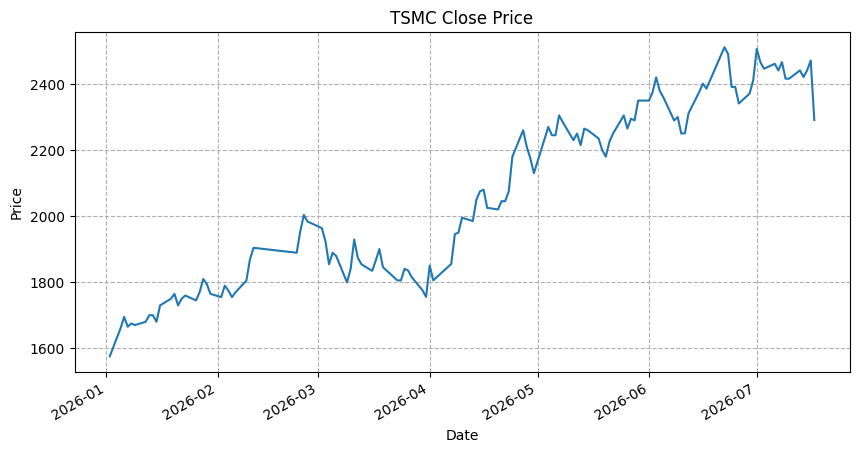

In [61]:
# 股價走勢
df["Close"].plot(figsize=(10,5))
plt.title("TSMC Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# mplfinance

In [58]:
! pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.2 MB/s eta 0:00:00


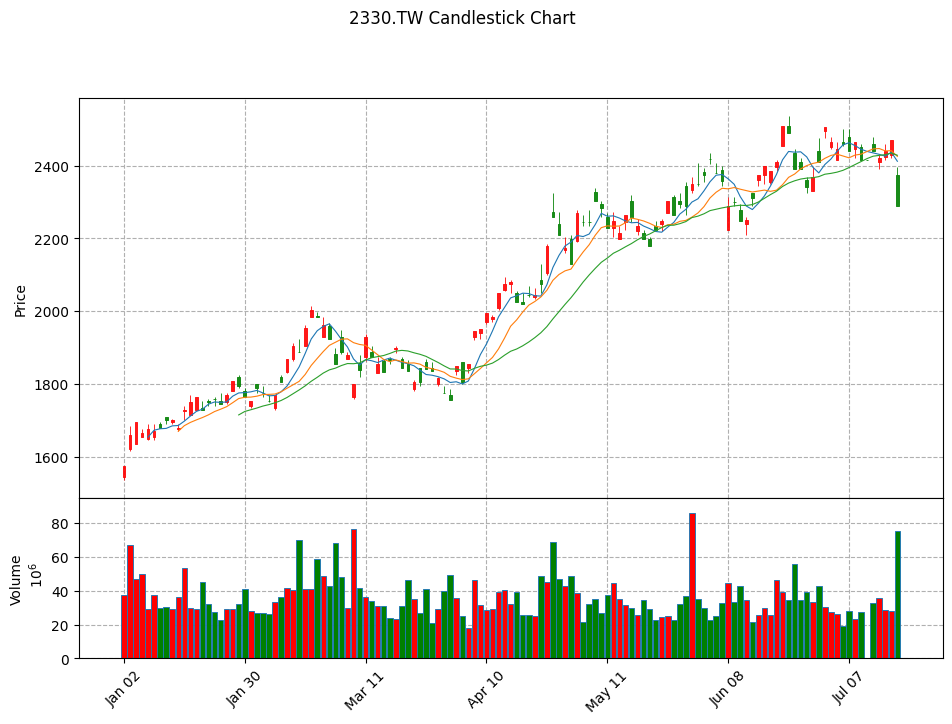

In [62]:
import mplfinance as mpf

mc = mpf.make_marketcolors(
    up='red', #　上漲
    down='green', # 下跌
    edge='inherit',
    wick='inherit',
    volume='inherit')

style = mpf.make_mpf_style(
    marketcolors=mc,
    gridstyle='--')

mpf.plot(
    df,
    type='candle', # K線圖
    style=style,
    mav=(5,10,20), # 均線
    volume=True, # 顯示成交量
    figsize=(12,8),
    title='2330.TW Candlestick Chart',
    ylabel='Price',
    ylabel_lower='Volume')

參考資料


https://finlab.finance/blog/python-global-index-yfinance-tutorial#yfinance-%E6%98%AF%E5%85%8D%E8%B2%BB%E7%9A%84%E5%97%8E%E6%9C%89%E5%AE%98%E6%96%B9%E6%94%AF%E6%8F%B4%E5%97%8E

https://ithelp.ithome.com.tw/articles/10341344